In [42]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns



In [43]:
df=pd.read_csv('credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## exploratory data analysis

In [44]:
df.shape

(32581, 12)

In [45]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB
None


In [46]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [47]:
df['loan_status'].unique()
#classification problem ...it mostly leads to class imbalance..jo value sabse xyada aati uspe model zyada foxus karta

array([1, 0])

In [48]:
df['loan_status'].value_counts()

loan_status
0    25473
1     7108
Name: count, dtype: int64

<Axes: xlabel='loan_status', ylabel='count'>

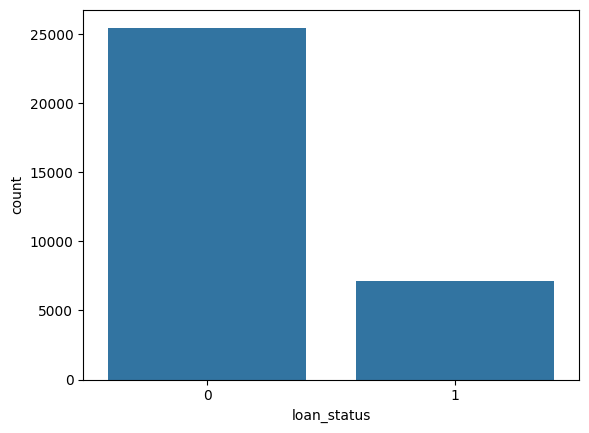

In [49]:
sns.countplot(x='loan_status',data=df)
#we can see simply thta there is a class imbalance 

In [50]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


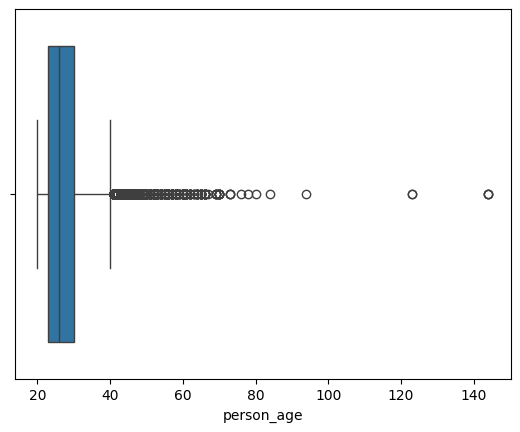

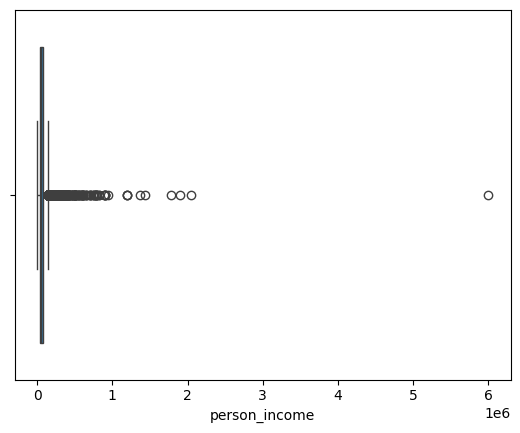

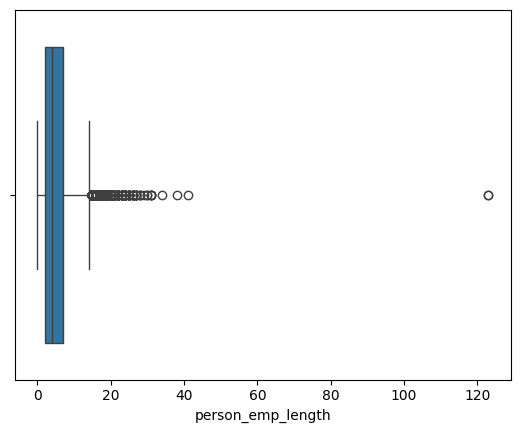

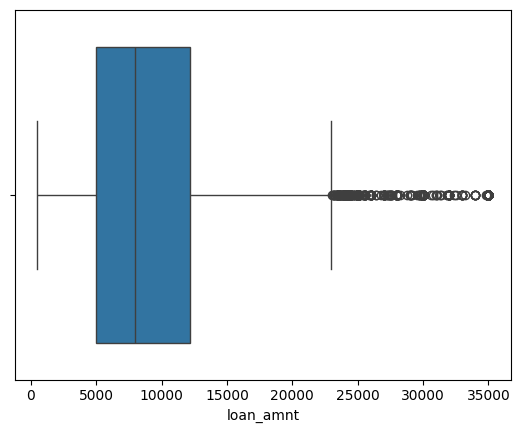

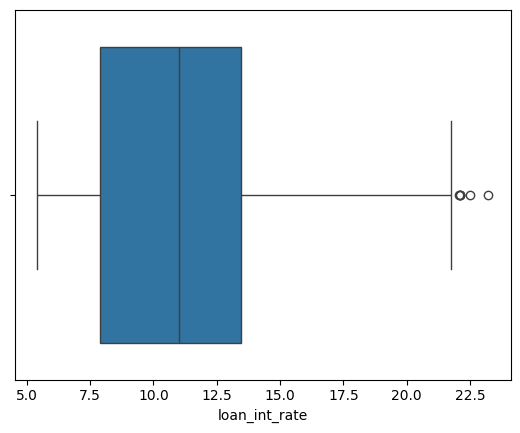

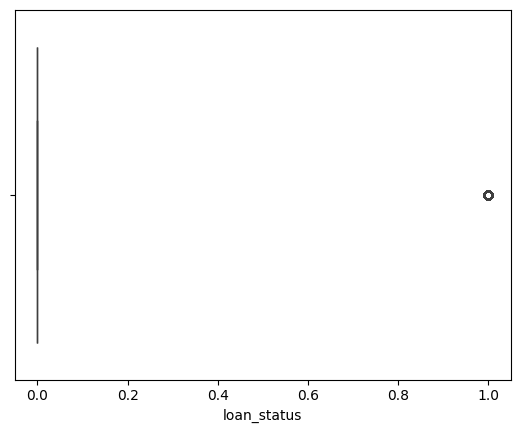

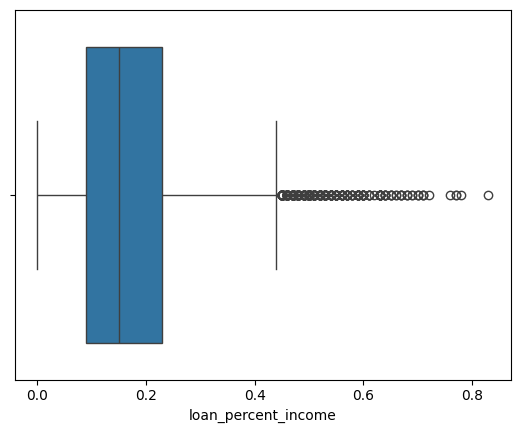

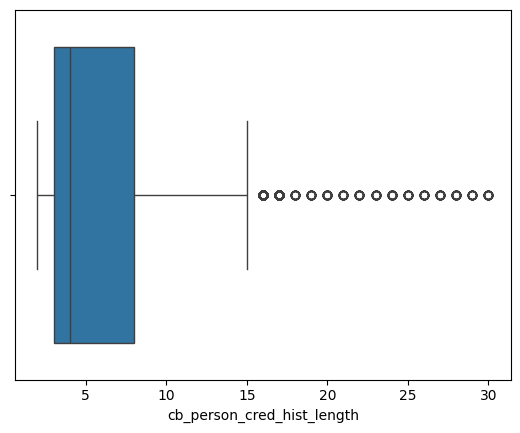

In [51]:
numerical_cols=df.select_dtypes(include=np.number).columns
for i in numerical_cols:
    sns.boxplot(x=df[i])
    plt.show()

In [52]:
(df['person_age']>100).sum() #we have 5 people whose age is greater than 100

np.int64(5)

In [53]:
(df['person_emp_length']>60).sum()

np.int64(2)

<Axes: >

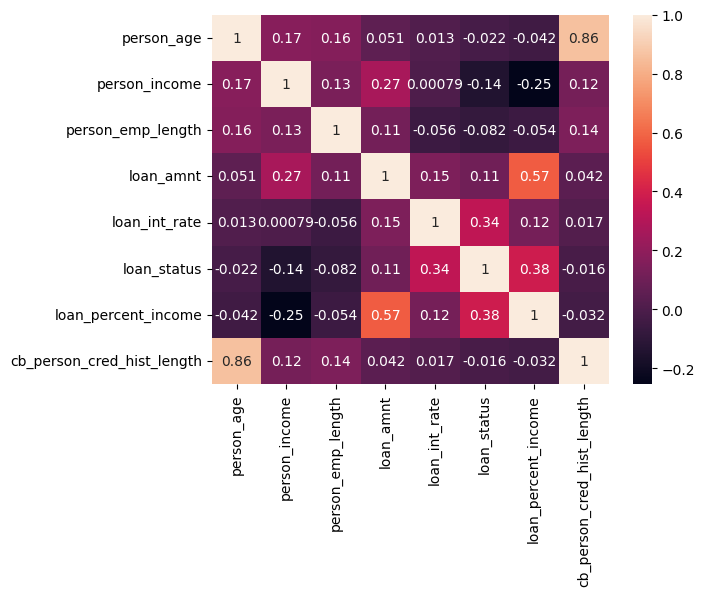

In [54]:
#correlation check 
sns.heatmap(df.corr(numeric_only=True),annot=True)

## Data Validation and outlier handling 

In [55]:
df_copy=df.copy()

In [56]:
#remove duplicate rows
print(f"original count of the rows: {df_copy.shape[0]}")
df_copy.drop_duplicates(inplace=True)
print(f"Row count after removing the duplicates {df_copy.shape[0]}")

original count of the rows: 32581
Row count after removing the duplicates 32416


In [57]:
# remove the ages below 18 and above 100 and remove employment greater than age or extreme outlier
df_copy=df_copy[(df_copy['person_age'] >= 18) & (df_copy['person_age'] <= 100)]
df_copy

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [58]:
df_copy=df_copy[(df_copy['person_emp_length']<=df_copy['person_age']) & (df_copy['person_emp_length']<=60)]
df_copy

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [59]:
#remove the rows with 0 or negative income and loan amount 
df_copy=df_copy[df_copy['loan_amnt']>0]

In [60]:
X=df_copy.drop('loan_status',axis=1)
y=df_copy['loan_status']

In [61]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
#stratify=y means equal amount of 0 and 1 should be  into training and testing 

In [62]:
numerical_cols=['person_age','person_income','person_emp_length','loan_amnt','loan_int_rate','loan_percent_income','cb_person_cred_hist_length']

categorical_cols=['person_home_ownership','loan_intent','loan_grade','cb_person_default_on_file']

## Handle class imablance

In [63]:
#class weights enables the model to pay attention on the class which is less so basicall ye bas minority class pe weights assign karta and fir hamara model us pe utna he equally dhyan dega 
#logiostic regression me class wright inbuilt hota hai 
#xgboost  dont have class weight 


#0-no laon 
#1- loan 
neg,pos=np.bincount(y_train) #0 hai 19772 and 1 hai 5445 same as value_counts
scale_weights=neg/pos #this is how we calculated the class wight for xgboost because it dont have inbuilt method 
scale_weights


np.float64(3.6312213039485766)

## Logistic Regression

In [64]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [65]:
#columntransformer columns ko respective pipeline me transform karta 
preprocessor_lr=ColumnTransformer(
    transformers=[
        #pipeline for numerical columns
        ('num',Pipeline([
            ('imputer',SimpleImputer(strategy='median')),
            ('scaler',StandardScaler())
        ]),numerical_cols),
         #pipeline for categorical columns
        ('cat',Pipeline([
            ('imputer',SimpleImputer(strategy='constant',fill_value="Missing")),
            ('encode',OneHotEncoder(handle_unknown='ignore'))
        ]),categorical_cols)
    ]
)

## XGBoost pipeline 

In [66]:
#no scaling for xgboost because it is a tree based model 
preprocessor_xg=ColumnTransformer(
    transformers=[
        #pipeline for numerical columns
        ('num',Pipeline([
            ('imputer',SimpleImputer(strategy='median'))
            
        ]),numerical_cols),

         #pipeline for categorical columns
        ('cat',Pipeline([
            ('imputer',SimpleImputer(strategy='constant',fill_value="Missing")),
            ('encode',OneHotEncoder(handle_unknown='ignore'))
        ]),categorical_cols)
    ]
)

In [67]:
from sklearn.model_selection import StratifiedKFold
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=True)
scoring={'accuracy':'accuracy','roc_auc':'roc_auc','precision':'precision','recall':'recall','f1':'f1'}


In [68]:
from sklearn.linear_model import LogisticRegression
lr_cv_pipeline=Pipeline([
    ('preprocessor',preprocessor_lr),
    ('classifier',LogisticRegression(max_iter=1000,class_weight='balanced',random_state=42))
])
lr_cv_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('encode',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [69]:
from xgboost import XGBClassifier
xgb_cv_pipeline=Pipeline([
    ('preprocessor',preprocessor_xg),
    ('classifier',XGBClassifier(n_estimator=300,max_depth=5,learning_rate=0.1,random_state=42,scale_pos_weghts=scale_weights))
])
xgb_cv_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='consta...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimator=300, n_estimators=None, n_jobs=None, ...))])

In [70]:
from sklearn.model_selection import cross_validate
for name,pipe in [("Logistic Regression",lr_cv_pipeline),("Xgboost",xgb_cv_pipeline)]:
    cv_results=cross_validate(pipe,X_train,y_train,cv=cv,scoring=scoring,n_jobs=-1)
    print(name)
    print(f"ROC-AUC {cv_results['test_roc_auc'].mean()}")
    print(f"Accuracy {cv_results['test_accuracy'].mean()}")
    print(f"precision {cv_results['test_precision'].mean()}")
    print(f"Recall {cv_results['test_recall'].mean()}")
    print(f"f1 score  {cv_results['test_f1'].mean()}")

Logistic Regression
ROC-AUC 0.8706739431147925
Accuracy 0.8119125874340309
precision 0.5452663651328141
Recall 0.7766758494031221
f1 score  0.6406927611333023
Xgboost
ROC-AUC 0.9383273487180404
Accuracy 0.9335370060147286
precision 0.9711950681976085
Recall 0.7134986225895317
f1 score  0.8224766385856576


In [71]:
cv_results

{'fit_time': array([0.39908433, 0.41708422, 0.39256644, 0.41708255, 0.37408853]),
 'score_time': array([0.04300022, 0.03900099, 0.03851962, 0.04500198, 0.0389986 ]),
 'test_accuracy': array([0.92862807, 0.93576527, 0.93139005, 0.93634741, 0.93555423]),
 'test_roc_auc': array([0.93875231, 0.94113378, 0.93562505, 0.94185416, 0.93427144]),
 'test_precision': array([0.98023715, 0.96589525, 0.95582822, 0.9729064 , 0.98110831]),
 'test_recall': array([0.68319559, 0.728191  , 0.71533517, 0.72543618, 0.71533517]),
 'test_f1': array([0.80519481, 0.83036649, 0.81827731, 0.8311415 , 0.82740308])}

In [87]:
#evaluator 
from sklearn.metrics import accuracy_score,precision_recall_curve,precision_score,recall_score,f1_score,confusion_matrix,classification_report
def evaluate_model(model_name,model,X_test,y_test,threshold=None):
    y_pred=model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    if threshold:
        y_pred = (y_pred_prob > threshold).astype(int)
    else:
        y_pred = model.predict(X_test)
    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    cm=confusion_matrix(y_test,y_pred)
    class_report=classification_report(y_test,y_pred)
    print(f"{model_name} Metrics:")
    if threshold is not None: # Only print threshold if provided
        print(f"Used Threshold : {threshold:.2f}")
    print(f"Accuracy {accuracy:.2f}")
    print(f"Precision {precision:.2f}")
    print(f"recall {recall:.2f}")
    print(f"f1 score {f1:.2f}")
    print(f"{model_name} classfication report")
    print(f"{class_report}")
    sns.heatmap(cm,annot=True,fmt="d")
    plt.title(f"{model_name} Confusion matrix")
    plt.ylabel("actual values")
    plt.xlabel("predicted values")
    plt.show()

    #plotting roc-auc curve
    precsions,recalls,threshold=precision_recall_curve(y_test,y_pred_prob)
    plt.plot(recalls,precsions)
    plt.xlabel("Recall")
    plt.ylabel("precision")
    plt.title(f"{model_name} precision recall curve")
    plt.show()

In [73]:
baseline_model=Pipeline([
    ("preprocessor",preprocessor_lr),
    ("classifier",LogisticRegression(class_weight="balanced"))
])
baseline_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('encode',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['person_home_ownership',
                                                   'loan_intent', 'loan_grade',
                                                   'cb_person_default_on_file'])])),
                ('classifier', LogisticRegression(class_weight='balanced'))])

In [74]:
xgb_model=Pipeline([
    ('preprocessor',preprocessor_xg),
    ('classifier',XGBClassifier(learning_rate=0.1,random_state=42,scale_pos_weight=scale_weights))
])
xgb_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['person_age',
                                                   'person_income',
                                                   'person_emp_length',
                                                   'loan_amnt', 'loan_int_rate',
                                                   'loan_percent_income',
                                                   'cb_person_cred_hist_length']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='consta...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

Accuracy 0.82
Precision 0.56
recall 0.79
f1 score 0.65
baseline model classfication report
              precision    recall  f1-score   support

           0       0.93      0.83      0.88      4943
           1       0.56      0.79      0.65      1362

    accuracy                           0.82      6305
   macro avg       0.75      0.81      0.77      6305
weighted avg       0.85      0.82      0.83      6305



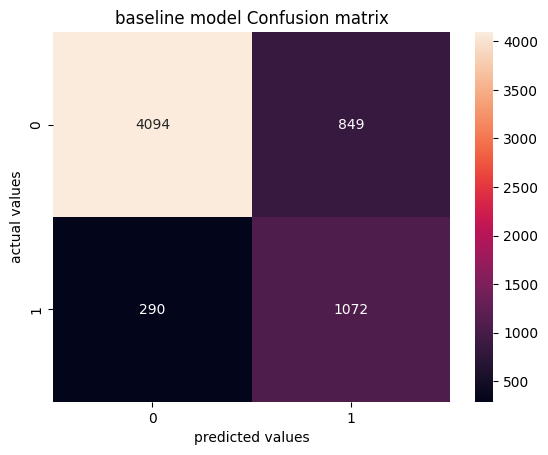

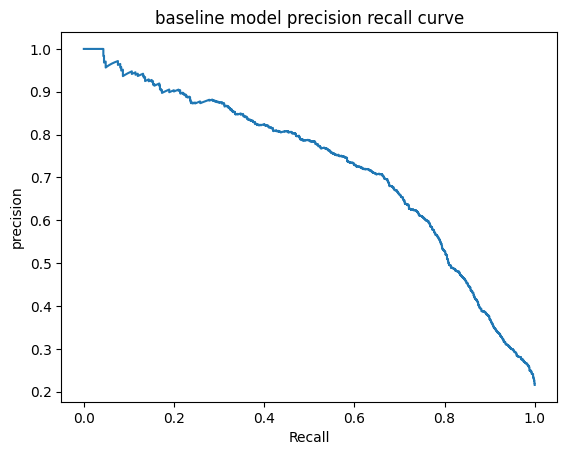

In [75]:
evaluate_model("baseline model",baseline_model,X_test,y_test)

Accuracy 0.92
Precision 0.82
recall 0.79
f1 score 0.80
xgboost classfication report
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      4943
           1       0.82      0.79      0.80      1362

    accuracy                           0.92      6305
   macro avg       0.88      0.87      0.88      6305
weighted avg       0.92      0.92      0.92      6305



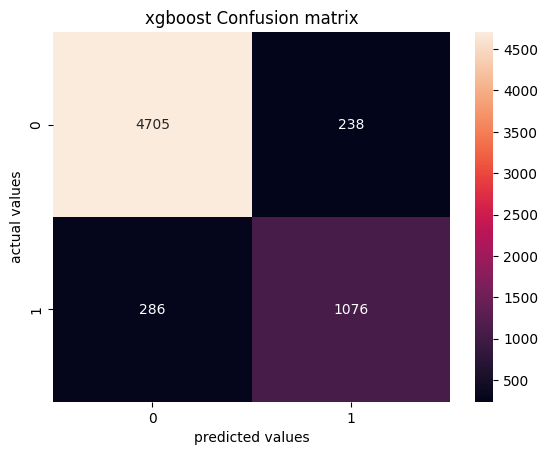

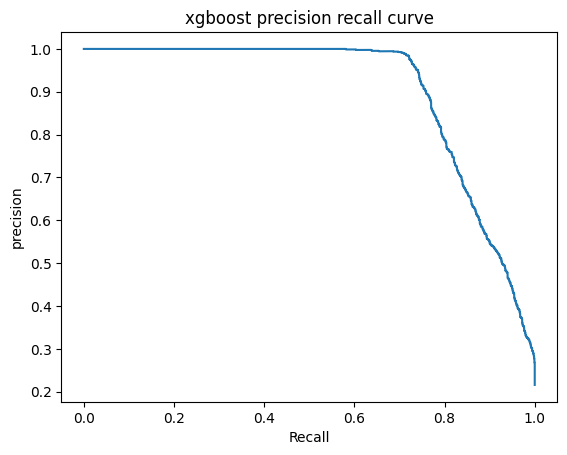

In [76]:
evaluate_model("xgboost",xgb_model,X_test,y_test)

## hyperparameter tuning

In [77]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform,randint
param_grid={
    "classifier__n_estimators":randint(150,600),
    "classifier__max_depth":randint(3,9),
    "classifier__learning_rate" : uniform(0.01, 0.5),
    "classifier__subsample": uniform(0.6,0.4), #Rows sampling
    "classifier__colsample_bytree" :uniform(0.6,0.4), #column sampling
    "classifier__min_child_weight": randint(1, 10),
    "classifier__gamma": uniform(0 , 5)
}
# lower gamma -> more splits -> complex tree -> higher overfitting risk
# higher gamma -> less splits ->  simpler tree -> low overfitting


In [78]:
random_search=RandomizedSearchCV(
    xgb_model,
    param_grid,
    cv=cv,
    n_iter=150,
    scoring='average_precision',
    n_jobs=-1,
    verbose=1

)
random_search.fit(X_train,y_train)

Fitting 5 folds for each of 150 candidates, totalling 750 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=True, shuffle=True),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['person_age',
                                                                                'person_income',
                                                                                'person_emp_length',
                                                                                'loan_amnt',
                                                                                'loan_int_rate',
                                                                                'loan_percent_income',
                                                                                'cb_person_cred_hist_leng...
                                        'classifier__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000022842386890>,
                                        'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x00000228423005E0>,
                                        'classifier__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000022842386B30>},
                   scoring='average_precision', verbose=1)

In [79]:
random_search.best_params_

{'classifier__colsample_bytree': np.float64(0.6077636085891603),
 'classifier__gamma': np.float64(0.3647895434908016),
 'classifier__learning_rate': np.float64(0.0676749736345129),
 'classifier__max_depth': 8,
 'classifier__min_child_weight': 3,
 'classifier__n_estimators': 393,
 'classifier__subsample': np.float64(0.937308993926199)}

In [80]:
print(f"score after tuning the model {random_search.best_score_:.2f}")

score after tuning the model 0.90


Accuracy 0.93
Precision 0.87
recall 0.79
f1 score 0.83
XGBClassifier classfication report
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      4943
           1       0.87      0.79      0.83      1362

    accuracy                           0.93      6305
   macro avg       0.90      0.88      0.89      6305
weighted avg       0.93      0.93      0.93      6305



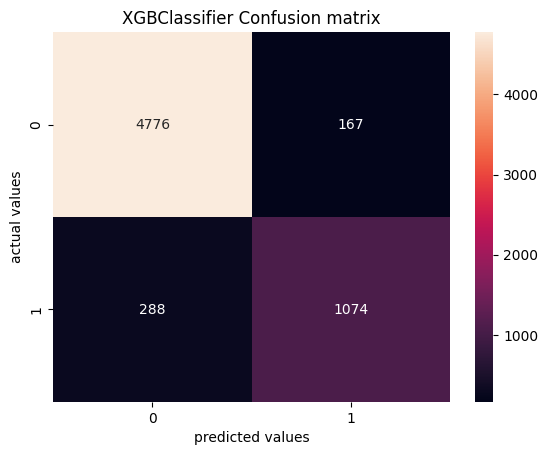

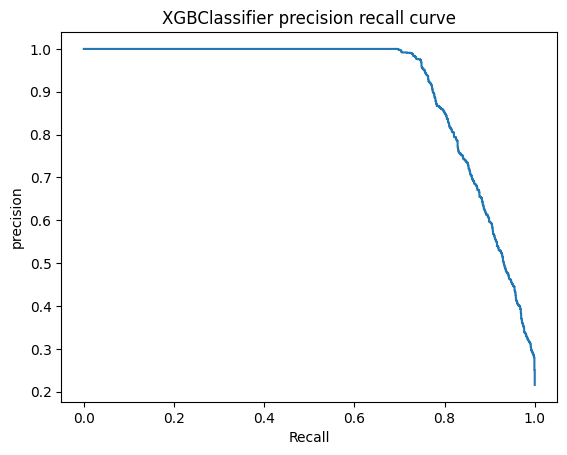

In [81]:
#checking the evaluation after hyper parameter tuning 
evaluate_model("XGBClassifier",random_search,X_test,y_test)

XGBoost Metrics:
Used Threshold : 0.69
Accuracy 0.94
Precision 0.97
recall 0.75
f1 score 0.84
XGBoost classfication report
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      4943
           1       0.97      0.75      0.84      1362

    accuracy                           0.94      6305
   macro avg       0.95      0.87      0.90      6305
weighted avg       0.94      0.94      0.94      6305



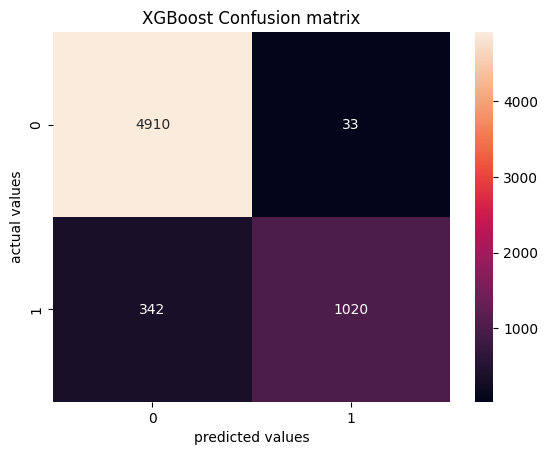

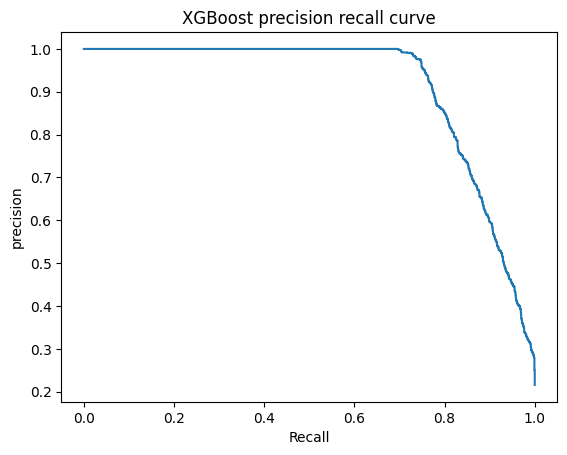

In [89]:
#get the probability of class 1 from xgboost 
prob=xgb_model.predict_proba(X_test)[:,1]

#for each threshold calculate the precsion and recall 
precisions,recalls,threshold=precision_recall_curve(y_test,prob)

#calulate the f1scor for threhsold
f1 = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)

#get the bets threshold value 
best=np.argmax(f1[:-1])
best_threshold=threshold[best]
evaluate_model("XGBoost", random_search, X_test, y_test,best_threshold)